In [116]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# import standard scaler
from sklearn.preprocessing import StandardScaler
# import spearmanr and pearsonr
from scipy.stats import spearmanr, pearsonr

In [19]:
# read in tsv file and print as dataframe
df = pd.read_csv('/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/mpra_experiment/proximal_regulators.tsv.gz', sep='\t')
df.head()

,newID,name,log2_HepG2,log2_HEK293T,label
0,oligo_000002,C:chr3:110657652-110657851(+)_FOXA1_FOXA2-NoMo...,0.857804,-0.747263,liverMPRA_(+)
1,oligo_000003,C:chr10:129955318-129955517(+)_FOXA1-ChMod_chr...,1.590980,-0.129704,liverMPRA_(+)
2,oligo_000004,C:chr2:135849337-135849536(+)_HNF4A-NoMod_chr2...,-0.099864,-1.108814,liverMPRA_(+)
3,oligo_000005,C:chr20:54933686-54933885(+)_EP300-NoMod_chr20...,0.548108,0.838090,liverMPRA_(+)
4,oligo_000006,C:chr6:1335679-1335878(+)_FOXA1_FOXA2-ChMod_ch...,0.383596,-0.250540,liverMPRA_(+)


In [6]:
# normalize log2 values using standardscalar
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['log2_HepG2', 'log2_HEK293T']] = scaler.fit_transform(df[['log2_HepG2', 'log2_HEK293T']])


In [20]:
# transform to long format using melt for log2_HepG2 and log2_HEK293T
merged_long = pd.melt(df, id_vars=['label'], value_vars=['log2_HepG2', 'log2_HEK293T'])
merged_long.head()

,label,variable,value
0,liverMPRA_(+),log2_HepG2,0.857804
1,liverMPRA_(+),log2_HepG2,1.590980
2,liverMPRA_(+),log2_HepG2,-0.099864
3,liverMPRA_(+),log2_HepG2,0.548108
4,liverMPRA_(+),log2_HepG2,0.383596


In [21]:
# print all unique label
print(merged_long['label'].unique())

['liverMPRA_(+)' 'liverMPRA_controls' 'liverMPRA_(-)'
 'liverMPRA_inBetween' 'DNAse_(-)_blood' 'DNAse_(-)_brain' 'DNAse_(+)'
 'HAR_(-)' 'HAR_(+)' 'SatMut_all' 'BasVanStansel_all'
 'ProximalPromoterDesign']


In [22]:
# remove rows with labels not in ['liverMPRA_(+)' 'liverMPRA_(-)' 'DNAse_(-)_blood' 'DNAse_(-)_brain' 'DNAse_(+)' 'ProximalPromoterDesign']
merged_long = merged_long[merged_long['label'].isin(['liverMPRA_(+)', 'liverMPRA_(-)', 'DNAse_(-)_blood', 'DNAse_(-)_brain', 'DNAse_(+)', 'ProximalPromoterDesign'])]

In [23]:
# rename label 'ProximalPromoterDesign' to 'ProximalRegulatoryElements'
merged_long['label'] = merged_long['label'].replace('ProximalPromoterDesign', 'ProximalRegulatoryElements')

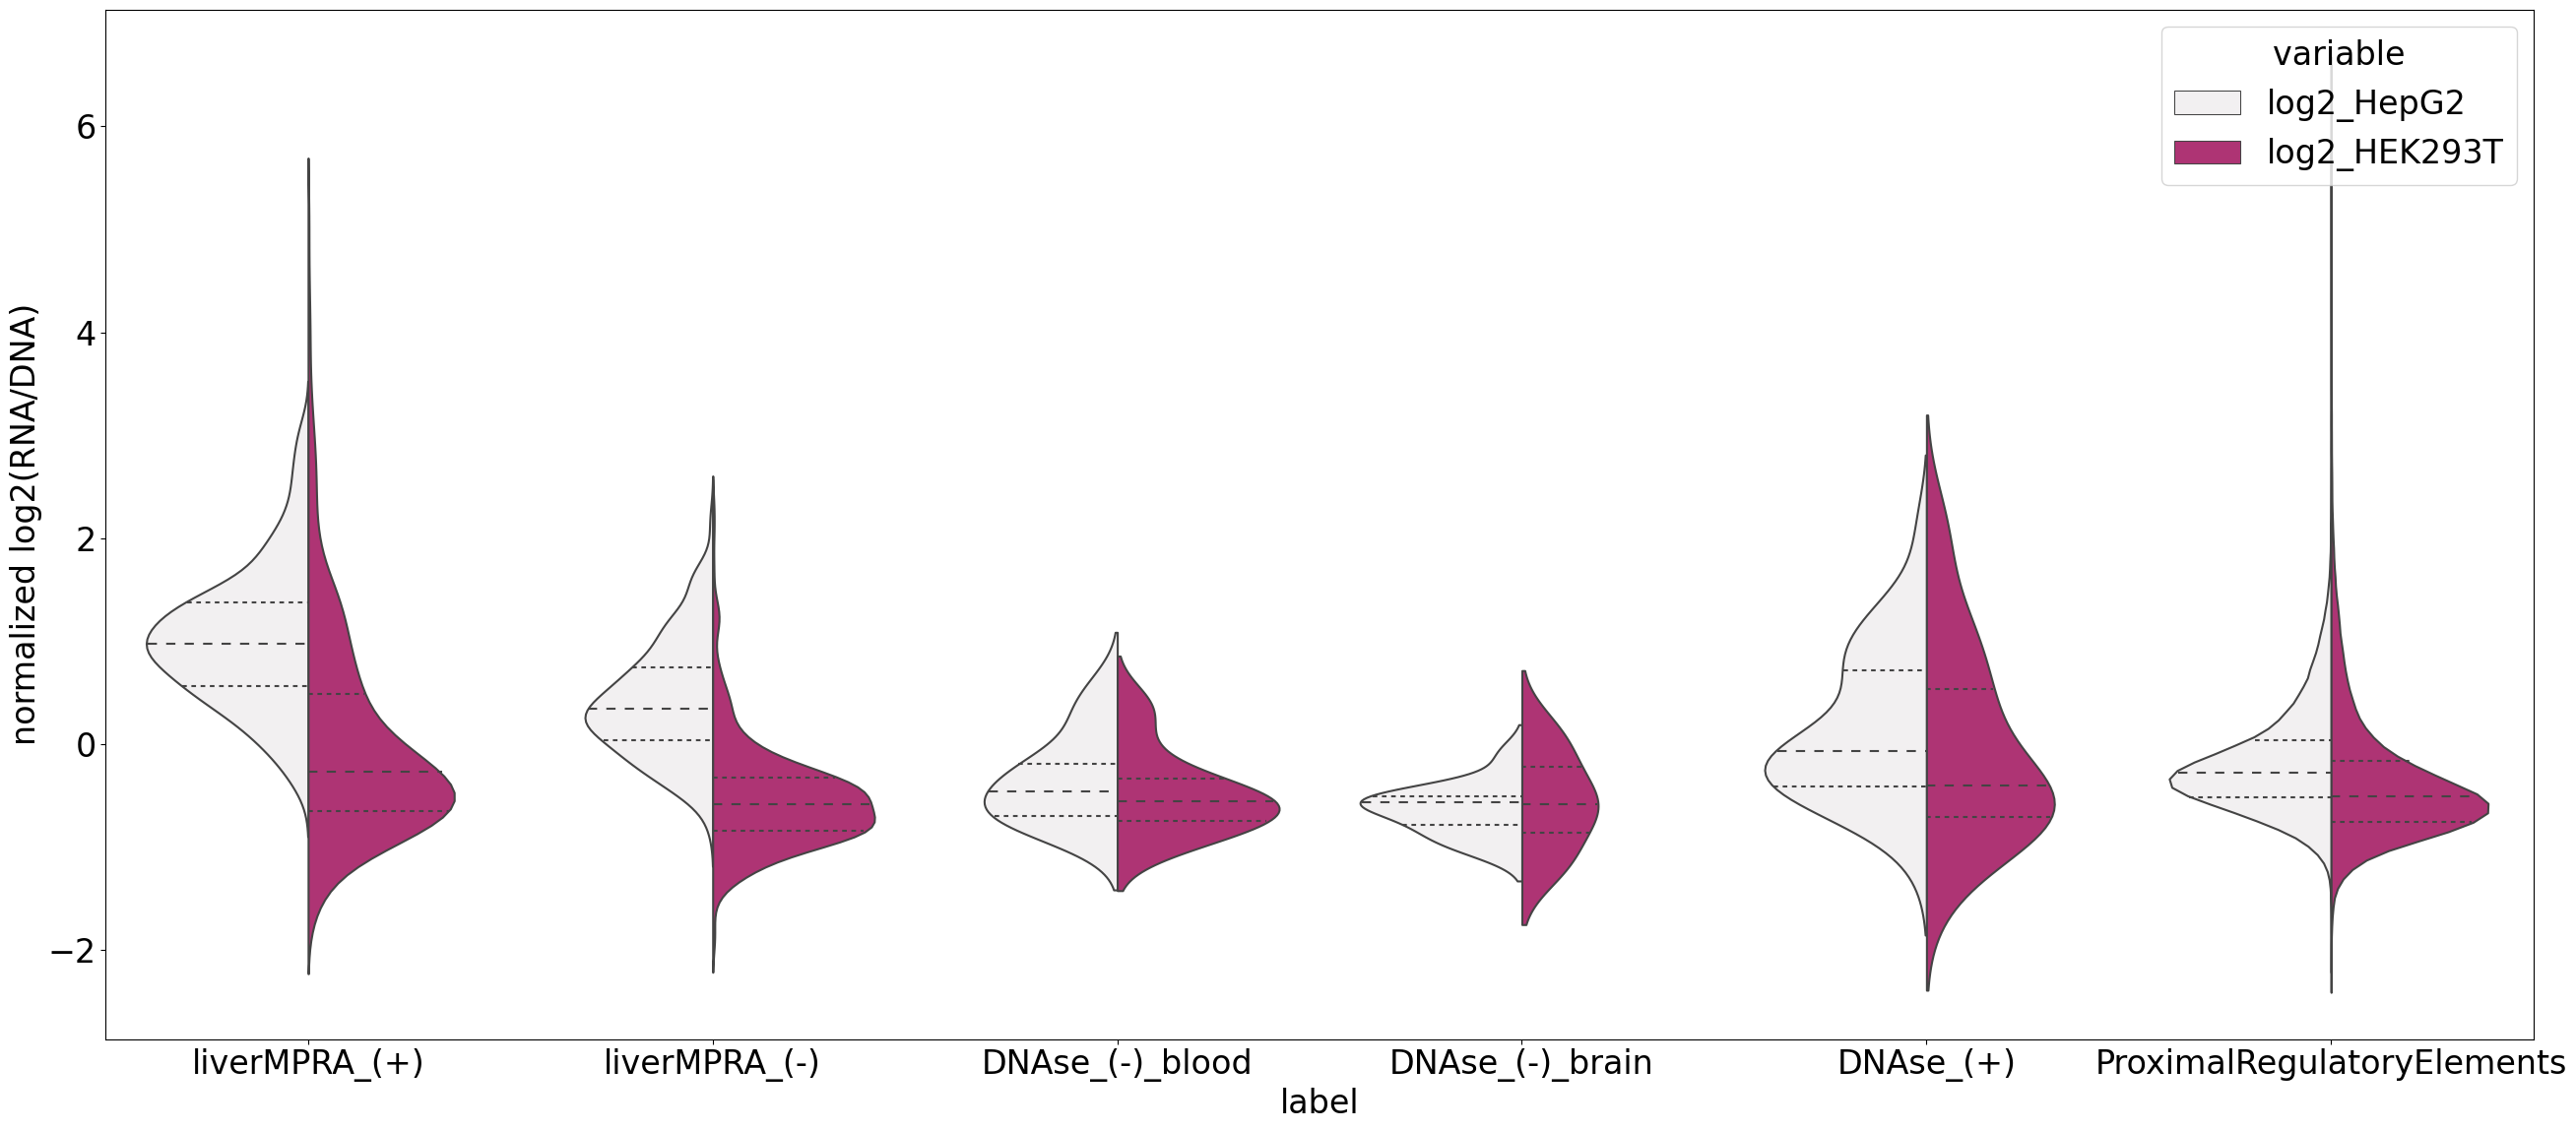

In [24]:
# violin plot (simple split)
fig, ax = plt.subplots(figsize=(27,12))
sns.violinplot(x='label', y='value', hue='variable', data=merged_long, ax=ax, color='#c22075', inner='quartile', split=True)
# axis labels
ax.set_xlabel('label')
ax.set_ylabel('normalized log2(RNA/DNA)')
plt.tight_layout()

# increase font size
plt.rcParams.update({'font.size': 24})
# save plot as png, 600dpi
# plt.savefig('violinplot_normalized.png', dpi=600)
plt.show()

### Normalize by DNase_(-)_blood and brain

In [69]:
# make a copy of df
df2 = df.copy()

In [70]:
# remove outliers in log2_HepG2 and log2_HEK293T if they are 5 standard deviations away from the mean in log2_HepG2 and log2_HEK293T
df2 = df2[(np.abs(stats.zscore(df2[['log2_HepG2', 'log2_HEK293T']])) < 5).all(axis=1)]
df2.shape

(200166, 5)

In [71]:
# normalize log2_HepG2 and log2_HEK293T by mean of DNAse_(-)_blood and DNAse_(-)_brain separately for each cell line
df2['log2_HepG2'] = df2['log2_HepG2'] - df2[df2['label'].isin(['DNAse_(-)_blood', 'DNAse_(-)_brain'])]['log2_HepG2'].mean()
df2['log2_HEK293T'] = df2['log2_HEK293T'] - df2[df2['label'].isin(['DNAse_(-)_blood', 'DNAse_(-)_brain'])]['log2_HEK293T'].mean()

In [72]:
# transform to long format using melt for log2_HepG2 and log2_HEK293T
merged_long2 = pd.melt(df2, id_vars=['label'], value_vars=['log2_HepG2', 'log2_HEK293T'])
merged_long2.head()

,label,variable,value
0,liverMPRA_(+),log2_HepG2,1.324740
1,liverMPRA_(+),log2_HepG2,2.057916
2,liverMPRA_(+),log2_HepG2,0.367072
3,liverMPRA_(+),log2_HepG2,1.015044
4,liverMPRA_(+),log2_HepG2,0.850532


In [73]:
# remove rows with labels not in ['liverMPRA_(+)' 'liverMPRA_(-)' 'DNAse_(-)_blood' 'DNAse_(-)_brain' 'DNAse_(+)' 'ProximalPromoterDesign']
merged_long2 = merged_long2[merged_long2['label'].isin(['liverMPRA_(+)', 'liverMPRA_(-)', 'DNAse_(-)_blood', 'DNAse_(-)_brain', 'DNAse_(+)', 'ProximalPromoterDesign'])]

# rename label 'ProximalPromoterDesign' to 'ProximalRegulatoryElements'
merged_long2['label'] = merged_long2['label'].replace('ProximalPromoterDesign', 'ProximalRegulatoryElements')

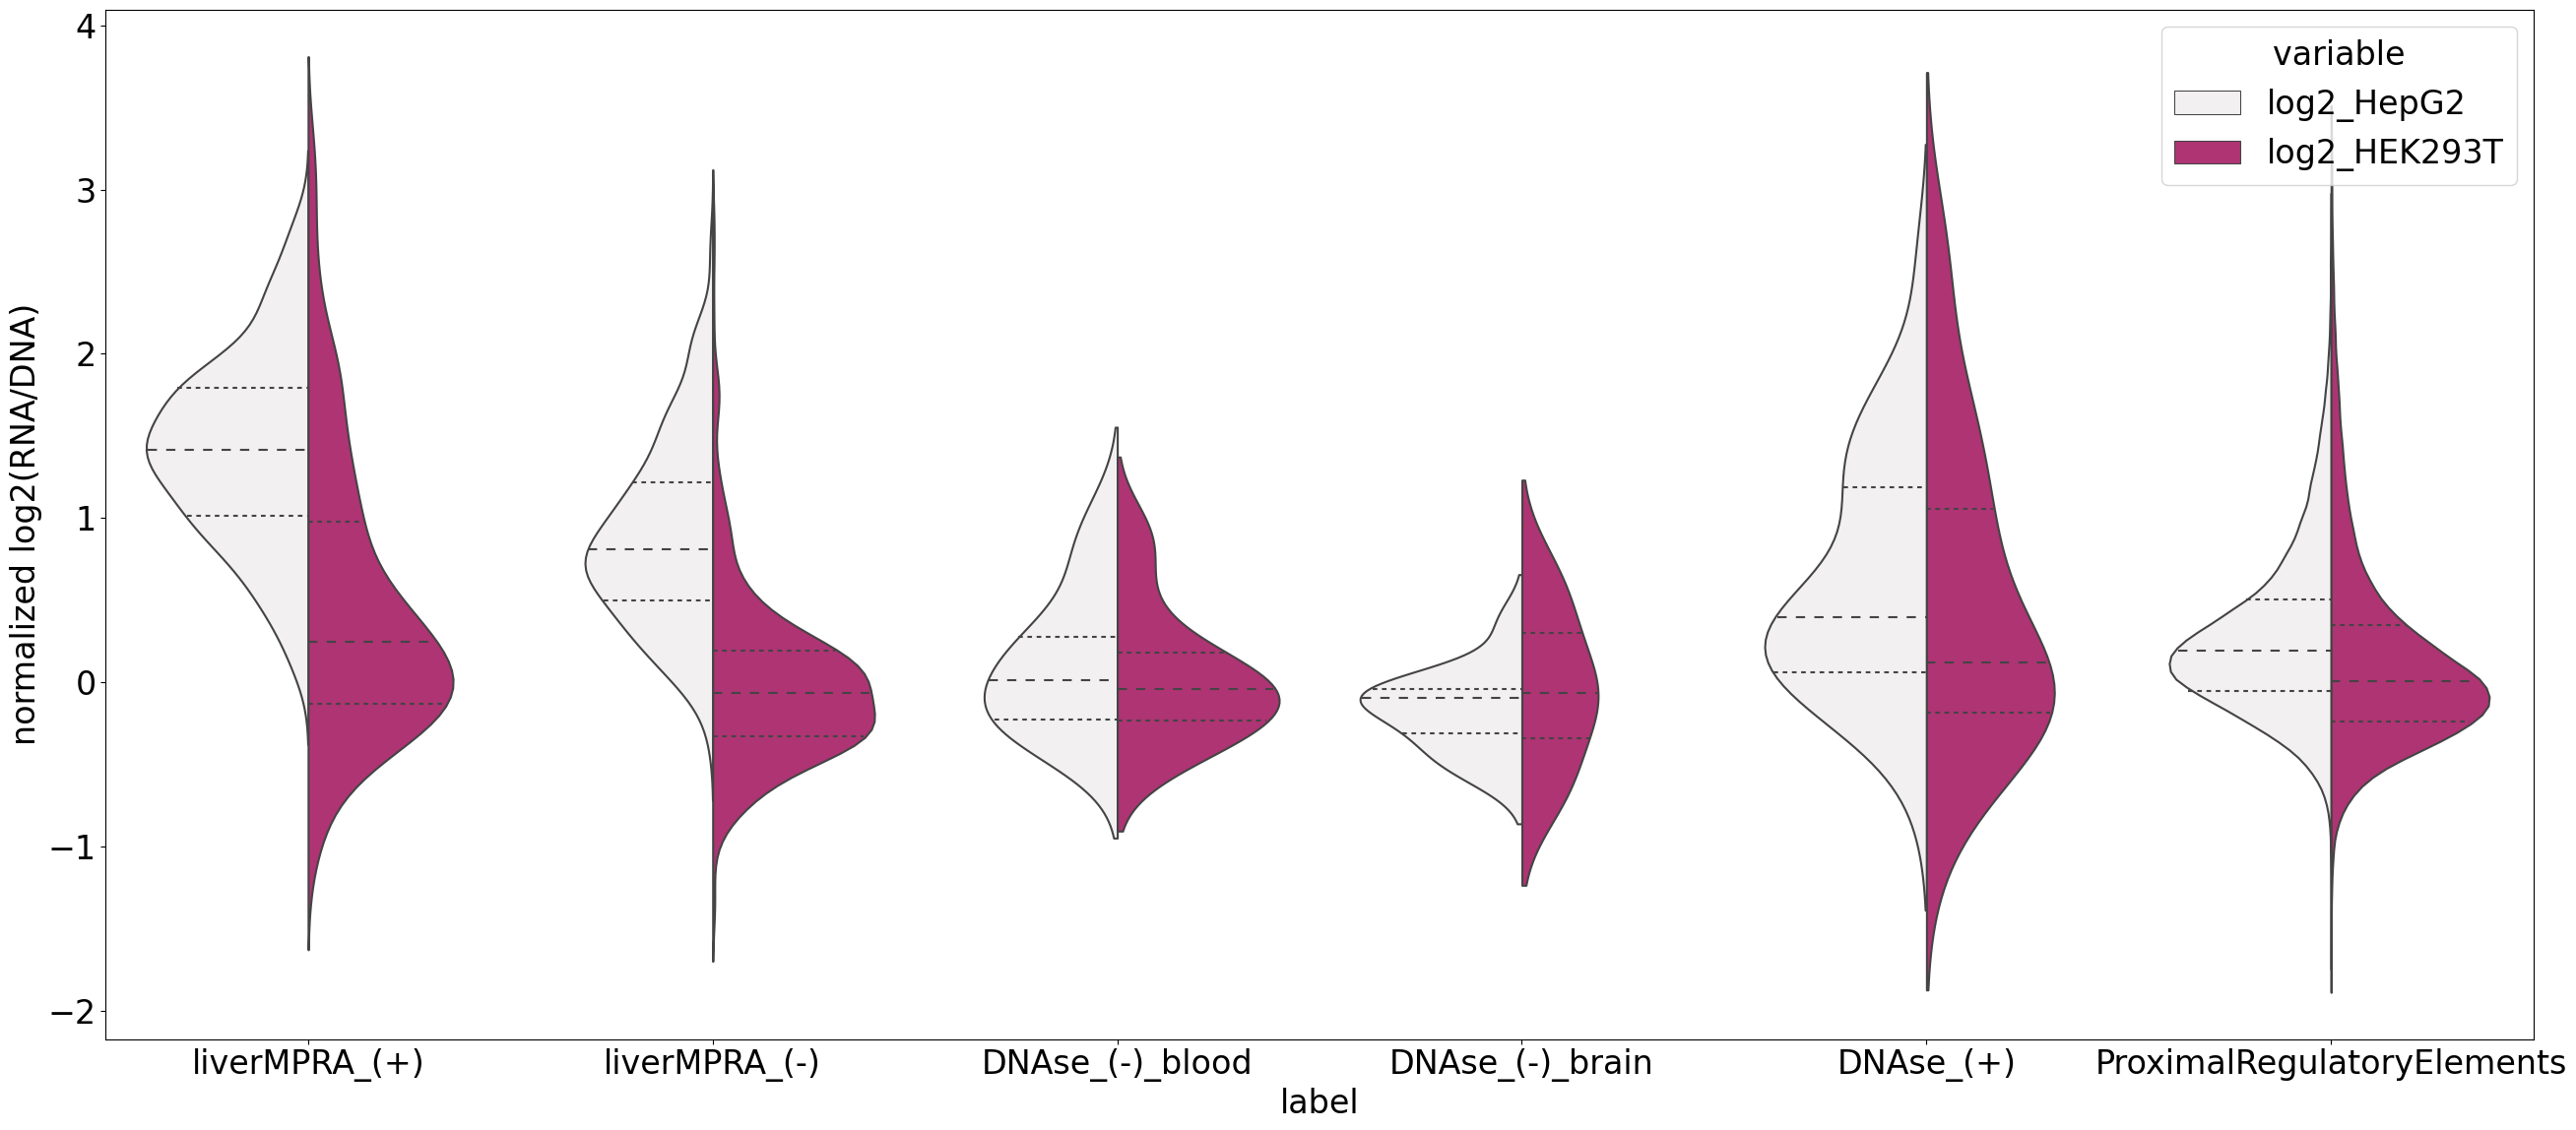

In [75]:
# violin plot (simple split)
fig, ax = plt.subplots(figsize=(27,12))
sns.violinplot(x='label', y='value', hue='variable', data=merged_long2, ax=ax, color='#c22075', inner='quartile', split=True)
# axis labels
ax.set_xlabel('label')
ax.set_ylabel('normalized log2(RNA/DNA)')
plt.tight_layout()

# increase font size
plt.rcParams.update({'font.size': 24})
# save plot as png, 600dpi
plt.savefig('violinplot_normalized_control.png', dpi=600)
# plt.show()

### Enformer, Sei predictions

In [80]:
# read tsv file
esp = pd.read_csv('/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/variant_analysis/enf_mprann_sei.tsv.gz', sep='\t')
esp.head()

,var_id,Enformer_HepG2,Enformer_K562,Enformer_HEK293T,Enformer_GM23248,Enformer_iPS_DF_19_11,chrom_pos_ref_alt_x,MPRAnn_HepG2,MPRAnn_HEK293T,MPRAnn_K562,MPRAnn_GM23248,MPRAnn_iPS_DF_19_11,Sei_iPS_DF_19.11_iPSC_Foreskin | DNase | ID:1890,Sei_Fibroblast_Skin | DNase | ID:40596,Sei_HEK293T_Epithelium_Embryonic_Kidney | DNase | ID:40986,Sei_HepG2 | DNase | ENCODE,Sei_K562 | DNase | ENCODE
0,chr1-822969-A-T,0.879198,-2.754967,-0.990487,1.260227,-0.355594,chr1-822969-A-T,-0.007499,-0.010041,-0.019753,-0.003139,-0.008909,0.000017,0.000015,5.598640e-07,0.000061,0.000164
1,chr1-825042-C-T,2.399578,-2.817618,-2.732483,-1.064522,1.267866,chr1-825042-C-T,0.094858,0.043365,-0.192181,0.265685,0.271926,0.000058,0.000363,4.212343e-06,0.000123,0.000728
2,chr1-832341-G-C,-24.728721,-37.823296,13.135035,12.411370,63.375553,chr1-832341-G-C,0.373082,0.310089,0.269268,0.384568,0.484821,0.720666,0.300638,1.821286e-03,0.329420,0.317398
3,chr1-832343-G-C,-21.949488,34.365176,6.564037,-0.898760,33.684574,chr1-832343-G-C,0.330342,0.320544,0.447513,0.351257,0.433832,0.719622,0.051402,7.171500e-04,0.379067,0.361889
4,chr1-832344-G-C,-1.913800,17.904733,3.474710,4.465758,-1.163874,chr1-832344-G-C,0.150811,0.028284,0.081742,-0.050133,-0.030412,0.069989,0.007363,3.482448e-05,0.019080,0.080833


In [81]:
# only keep var_id, Enformer_HepG2, Enformer_HEK293T, MPRAnn_HepG2, MPRAnn_HEK293T, Sei_HEK293T_Epithelium_Embryonic_Kidney | DNase | ID:40986, Sei_HepG2 | DNase | ENCODE
esp = esp[['var_id', 'Enformer_HepG2', 'Enformer_HEK293T', 'MPRAnn_HepG2', 'MPRAnn_HEK293T', 'Sei_HEK293T_Epithelium_Embryonic_Kidney | DNase | ID:40986', 'Sei_HepG2 | DNase | ENCODE']]

In [82]:
# rename Sei_HEK293T_Epithelium_Embryonic_Kidney | DNase | ID:40986 to Sei_HEK293T and Sei_HepG2 | DNase | ENCODE to Sei_HepG2
esp = esp.rename(columns={'Sei_HEK293T_Epithelium_Embryonic_Kidney | DNase | ID:40986': 'Sei_HEK293T', 'Sei_HepG2 | DNase | ENCODE': 'Sei_HepG2'})

In [83]:
esp.head()

,var_id,Enformer_HepG2,Enformer_HEK293T,MPRAnn_HepG2,MPRAnn_HEK293T,Sei_HEK293T,Sei_HepG2
0,chr1-822969-A-T,0.879198,-0.990487,-0.007499,-0.010041,5.598640e-07,0.000061
1,chr1-825042-C-T,2.399578,-2.732483,0.094858,0.043365,4.212343e-06,0.000123
2,chr1-832341-G-C,-24.728721,13.135035,0.373082,0.310089,1.821286e-03,0.329420
3,chr1-832343-G-C,-21.949488,6.564037,0.330342,0.320544,7.171500e-04,0.379067
4,chr1-832344-G-C,-1.913800,3.474710,0.150811,0.028284,3.482448e-05,0.019080


In [84]:
# read tsv file
vhek = pd.read_csv('/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/mpra_experiment/var_effect_hek.tsv.gz', sep='\t')
vhek.head()

,var_id,log2,log2_REF,log2(REF-ALT)
0,chr1-822969-A-T,-0.310566,-0.362546,-0.051980
1,chr1-825042-C-T,-0.440114,0.391153,0.831266
2,chr1-832341-G-C,-0.047441,-0.673523,-0.626082
3,chr1-832343-G-C,-1.148978,-0.673523,0.475455
4,chr1-836548-T-G,-0.402366,0.217428,0.619793


In [85]:
vhep = pd.read_csv('/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/mpra_experiment/var_effect_hepg2.tsv.gz', sep='\t')
vhep.head()

,var_id,log2,log2_REF,log2(REF-ALT)
0,chr1-822969-A-T,-0.655005,-0.647481,0.007524
1,chr1-825042-C-T,-0.649614,-0.915062,-0.265448
2,chr1-832341-G-C,-0.043377,-0.623346,-0.579969
3,chr1-832343-G-C,-0.268741,-0.623346,-0.354605
4,chr1-836548-T-G,-0.356718,-0.322821,0.033897


In [86]:
# rename log2(REF-ALT) to log2(REF-ALT)_HEK293T
vhek = vhek.rename(columns={'log2(REF-ALT)': 'log2(REF-ALT)_HEK293T'})

# rename log2(REF-ALT) to log2(REF-ALT)_HepG2
vhep = vhep.rename(columns={'log2(REF-ALT)': 'log2(REF-ALT)_HepG2'})

In [87]:
merge = pd.merge(vhek, vhep, on='var_id', how='inner')
merge.head()

,var_id,log2_x,log2_REF_x,log2(REF-ALT)_HEK293T,log2_y,log2_REF_y,log2(REF-ALT)_HepG2
0,chr1-822969-A-T,-0.310566,-0.362546,-0.051980,-0.655005,-0.647481,0.007524
1,chr1-825042-C-T,-0.440114,0.391153,0.831266,-0.649614,-0.915062,-0.265448
2,chr1-832341-G-C,-0.047441,-0.673523,-0.626082,-0.043377,-0.623346,-0.579969
3,chr1-832343-G-C,-1.148978,-0.673523,0.475455,-0.268741,-0.623346,-0.354605
4,chr1-836548-T-G,-0.402366,0.217428,0.619793,-0.356718,-0.322821,0.033897


In [88]:
# only keep var_id, log2(REF-ALT)_HEK293T, log2(REF-ALT)_HepG2
merge = merge[['var_id', 'log2(REF-ALT)_HEK293T', 'log2(REF-ALT)_HepG2']]
merge.head()

,var_id,log2(REF-ALT)_HEK293T,log2(REF-ALT)_HepG2
0,chr1-822969-A-T,-0.051980,0.007524
1,chr1-825042-C-T,0.831266,-0.265448
2,chr1-832341-G-C,-0.626082,-0.579969
3,chr1-832343-G-C,0.475455,-0.354605
4,chr1-836548-T-G,0.619793,0.033897


In [89]:
merge.shape

(102124, 3)

In [123]:
# merge with esp
merged = pd.merge(merge, esp, on='var_id', how='inner')
merged.head()

,var_id,log2(REF-ALT)_HEK293T,log2(REF-ALT)_HepG2,Enformer_HepG2,Enformer_HEK293T,MPRAnn_HepG2,MPRAnn_HEK293T,Sei_HEK293T,Sei_HepG2
0,chr1-822969-A-T,-0.051980,0.007524,0.879198,-0.990487,-0.007499,-0.010041,5.598640e-07,0.000061
1,chr1-825042-C-T,0.831266,-0.265448,2.399578,-2.732483,0.094858,0.043365,4.212343e-06,0.000123
2,chr1-832341-G-C,-0.626082,-0.579969,-24.728721,13.135035,0.373082,0.310089,1.821286e-03,0.329420
3,chr1-832343-G-C,0.475455,-0.354605,-21.949488,6.564037,0.330342,0.320544,7.171500e-04,0.379067
4,chr1-836548-T-G,0.619793,0.033897,1.741815,2.312297,0.011151,-0.341016,3.795922e-05,0.010954


In [124]:
# switch signs of all columns except first 3
merged.iloc[:, 3:] = -merged.iloc[:, 3:]

In [125]:
# reorder columns as var_id, log2(REF-ALT)_HepG2, Enformer_HepG2, MPRAnn_HepG2, Sei_HepG2, log2(REF-ALT)_HEK293T, Enformer_HEK293T,  MPRAnn_HEK293T, Sei_HEK293T 
merged = merged[['var_id', 'log2(REF-ALT)_HepG2', 'Enformer_HepG2', 'MPRAnn_HepG2', 'Sei_HepG2', 'log2(REF-ALT)_HEK293T', 'Enformer_HEK293T', 'MPRAnn_HEK293T', 'Sei_HEK293T']]
merged.head()

,var_id,log2(REF-ALT)_HepG2,Enformer_HepG2,MPRAnn_HepG2,Sei_HepG2,log2(REF-ALT)_HEK293T,Enformer_HEK293T,MPRAnn_HEK293T,Sei_HEK293T
0,chr1-822969-A-T,0.007524,-0.879198,0.007499,-0.000061,-0.051980,0.990487,0.010041,-5.598640e-07
1,chr1-825042-C-T,-0.265448,-2.399578,-0.094858,-0.000123,0.831266,2.732483,-0.043365,-4.212343e-06
2,chr1-832341-G-C,-0.579969,24.728721,-0.373082,-0.329420,-0.626082,-13.135035,-0.310089,-1.821286e-03
3,chr1-832343-G-C,-0.354605,21.949488,-0.330342,-0.379067,0.475455,-6.564037,-0.320544,-7.171500e-04
4,chr1-836548-T-G,0.033897,-1.741815,-0.011151,-0.010954,0.619793,-2.312297,0.341016,-3.795922e-05


In [126]:
# min-max normalization of all columns except var_id individually
merged.iloc[:, 1:] = (merged.iloc[:, 1:] - merged.iloc[:, 1:].min()) / (merged.iloc[:, 1:].max() - merged.iloc[:, 1:].min())


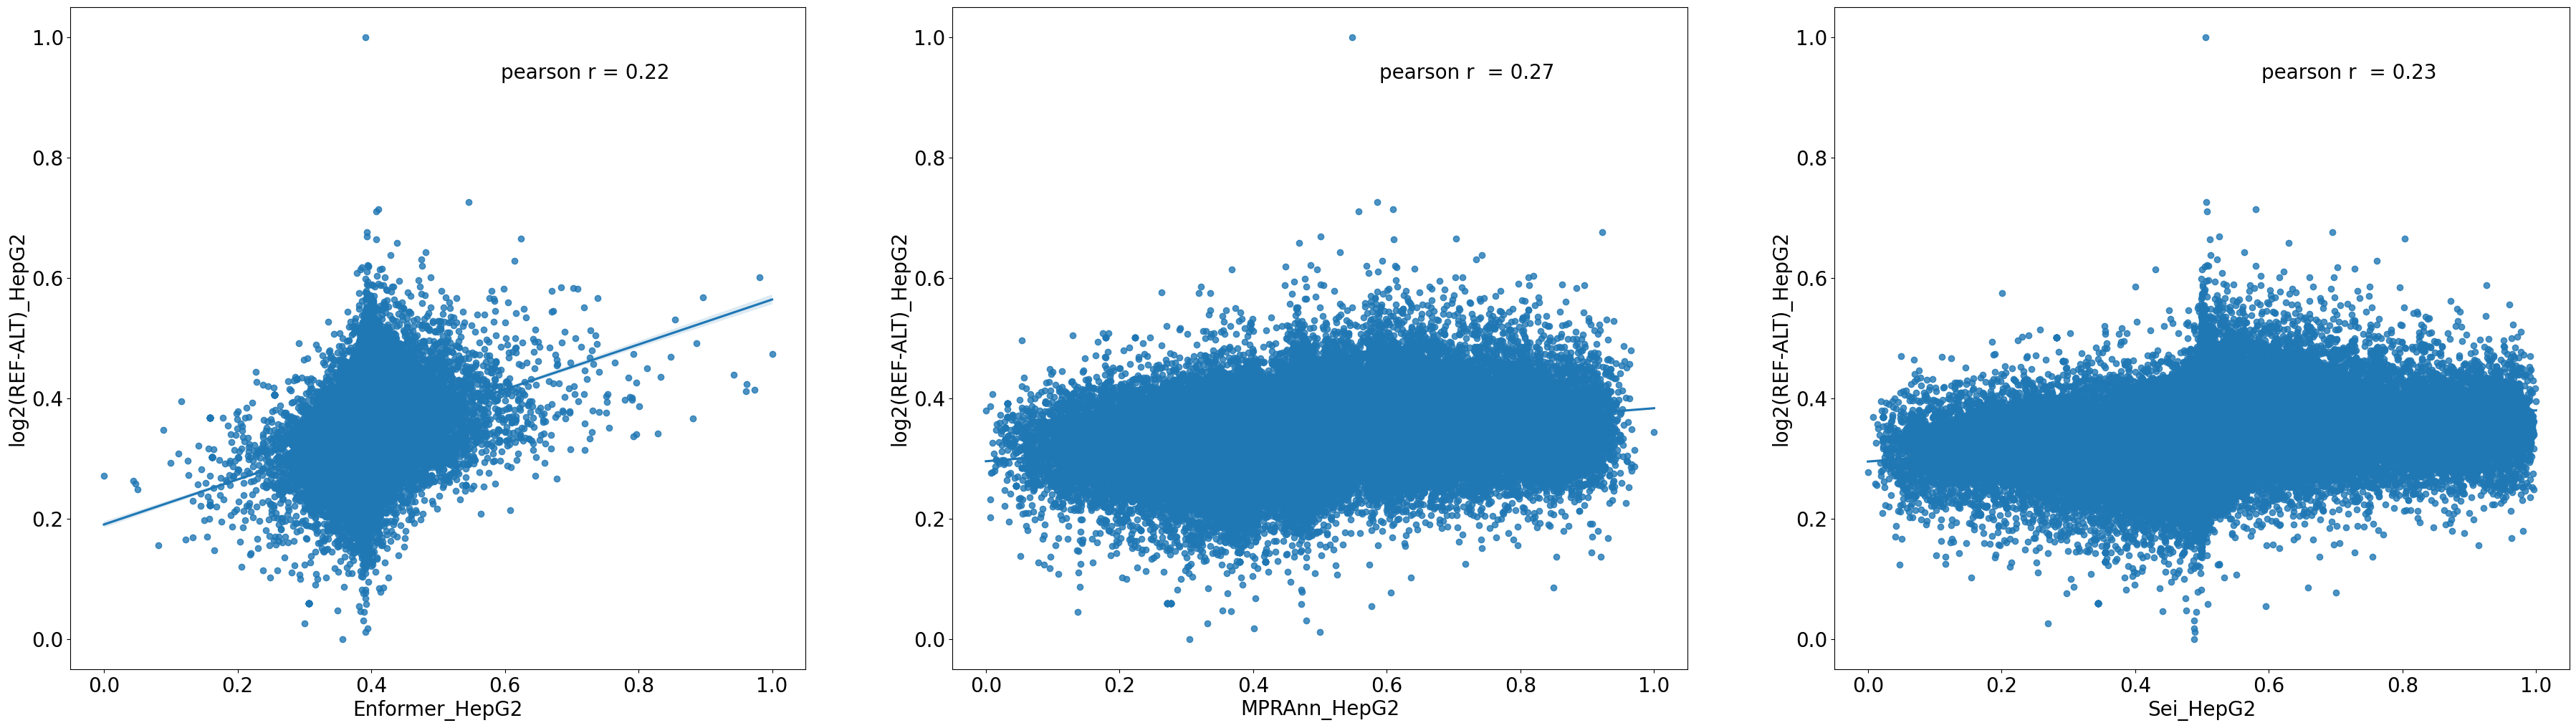

In [130]:
# plot pearson correlation of log2(REF-ALT)_HepG2 with Enformer_HepG2, MPRAnn_HepG2, Sei_HepG2 as subplots
# in x-axis its Enformer_HepG2, MPRAnn_HepG2, Sei_HepG2
# in y-axis its log2(REF-ALT)_HepG2
# also print out the pearson correlation coefficient in the plot on top right corner with 'pearson r'
fig, ax = plt.subplots(1, 3, figsize=(45,12))
sns.regplot(x='Enformer_HepG2', y='log2(REF-ALT)_HepG2', data=merged, ax=ax[0])
sns.regplot(x='MPRAnn_HepG2', y='log2(REF-ALT)_HepG2', data=merged, ax=ax[1])
sns.regplot(x='Sei_HepG2', y='log2(REF-ALT)_HepG2', data=merged, ax=ax[2])

# bring all in same scale

# add pearson correlation coefficient
r1, _ = pearsonr(merged['Enformer_HepG2'], merged['log2(REF-ALT)_HepG2'])
r2, _ = pearsonr(merged['MPRAnn_HepG2'], merged['log2(REF-ALT)_HepG2'])
r3, _ = pearsonr(merged['Sei_HepG2'], merged['log2(REF-ALT)_HepG2'])

ax[0].text(0.7, 0.9, 'pearson r = {:.2f}'.format(r1), horizontalalignment='center', verticalalignment='center', transform=ax[0].transAxes)
ax[1].text(0.7, 0.9, 'pearson r  = {:.2f}'.format(r2), horizontalalignment='center', verticalalignment='center', transform=ax[1].transAxes)
ax[2].text(0.7, 0.9, 'pearson r  = {:.2f}'.format(r3), horizontalalignment='center', verticalalignment='center', transform=ax[2].transAxes)

# increas
# save plot as png 300 dpi
plt.savefig('correlation_hepg2.png', dpi=300)

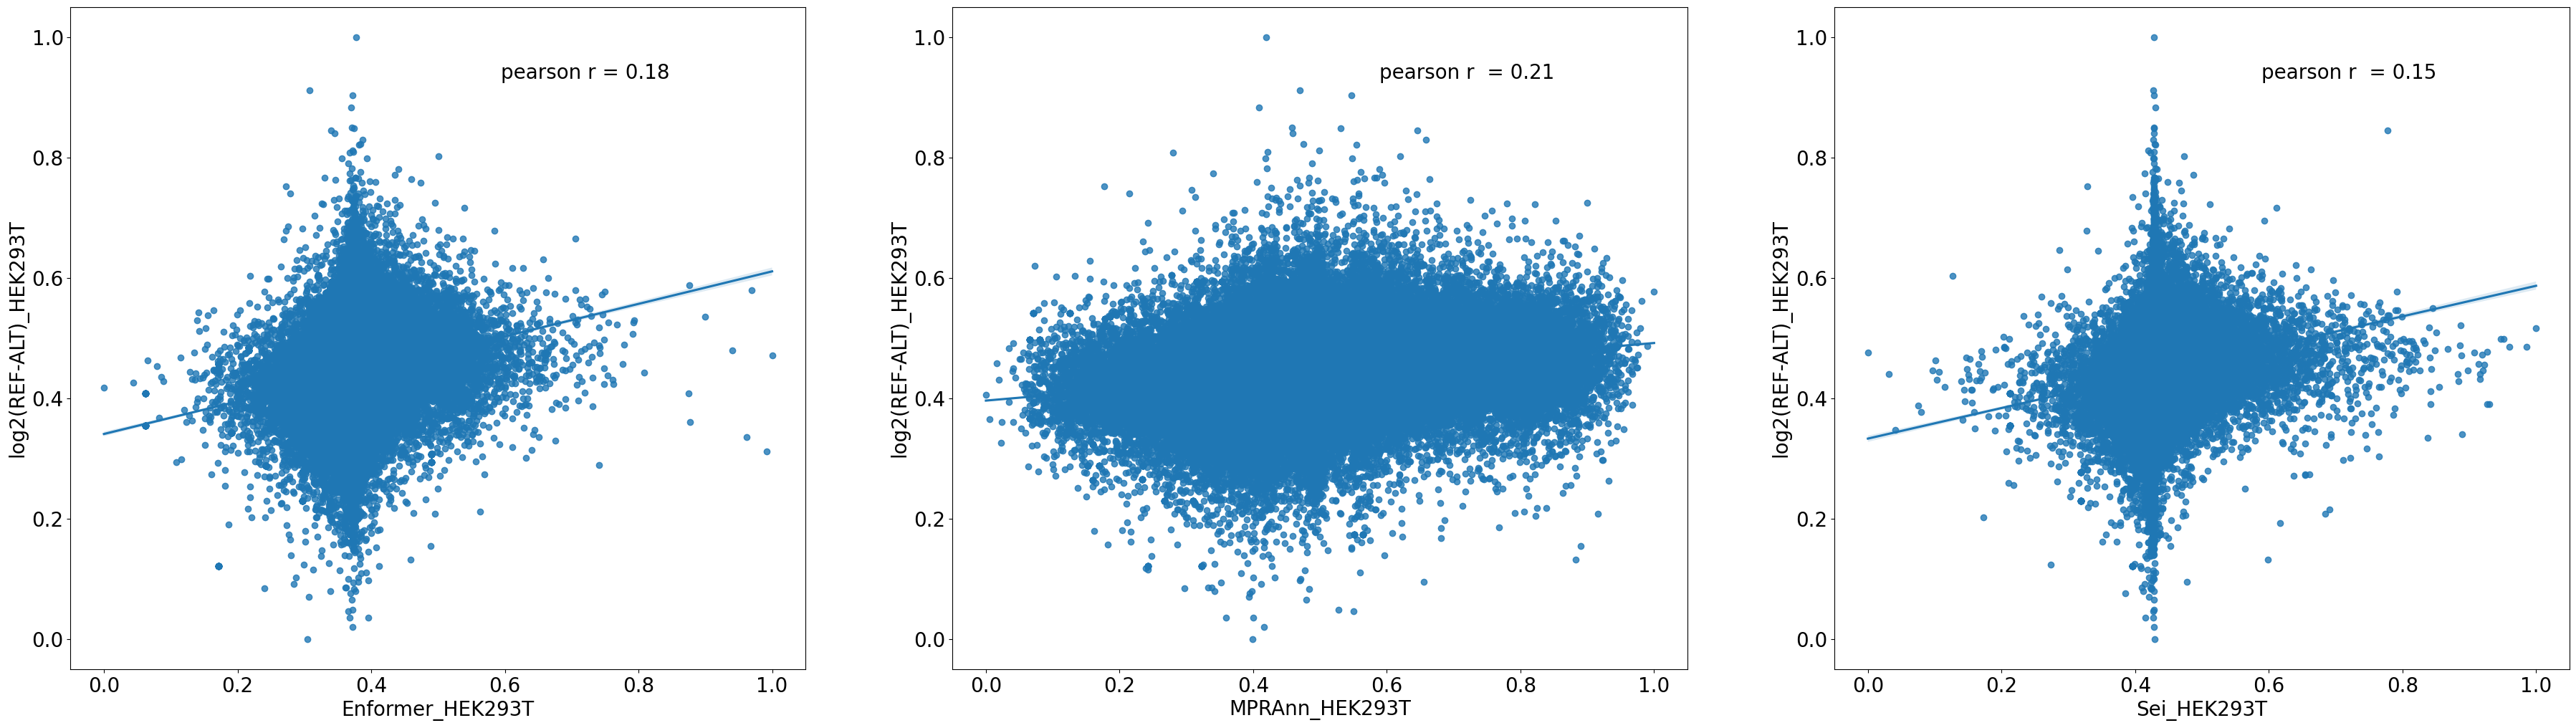

In [131]:
# try same plot but for HEK293T now
fig, ax = plt.subplots(1, 3, figsize=(45,12))
sns.regplot(x='Enformer_HEK293T', y='log2(REF-ALT)_HEK293T', data=merged, ax=ax[0])
sns.regplot(x='MPRAnn_HEK293T', y='log2(REF-ALT)_HEK293T', data=merged, ax=ax[1])
sns.regplot(x='Sei_HEK293T', y='log2(REF-ALT)_HEK293T', data=merged, ax=ax[2])

# bring all in same scale

# add pearson correlation coefficient
r1, _ = pearsonr(merged['Enformer_HEK293T'], merged['log2(REF-ALT)_HEK293T'])
r2, _ = pearsonr(merged['MPRAnn_HEK293T'], merged['log2(REF-ALT)_HEK293T'])
r3, _ = pearsonr(merged['Sei_HEK293T'], merged['log2(REF-ALT)_HEK293T'])

ax[0].text(0.7, 0.9, 'pearson r = {:.2f}'.format(r1), horizontalalignment='center', verticalalignment='center', transform=ax[0].transAxes)
ax[1].text(0.7, 0.9, 'pearson r  = {:.2f}'.format(r2), horizontalalignment='center', verticalalignment='center', transform=ax[1].transAxes)
ax[2].text(0.7, 0.9, 'pearson r  = {:.2f}'.format(r3), horizontalalignment='center', verticalalignment='center', transform=ax[2].transAxes)

plt.savefig('correlation_hek.png', dpi=300)

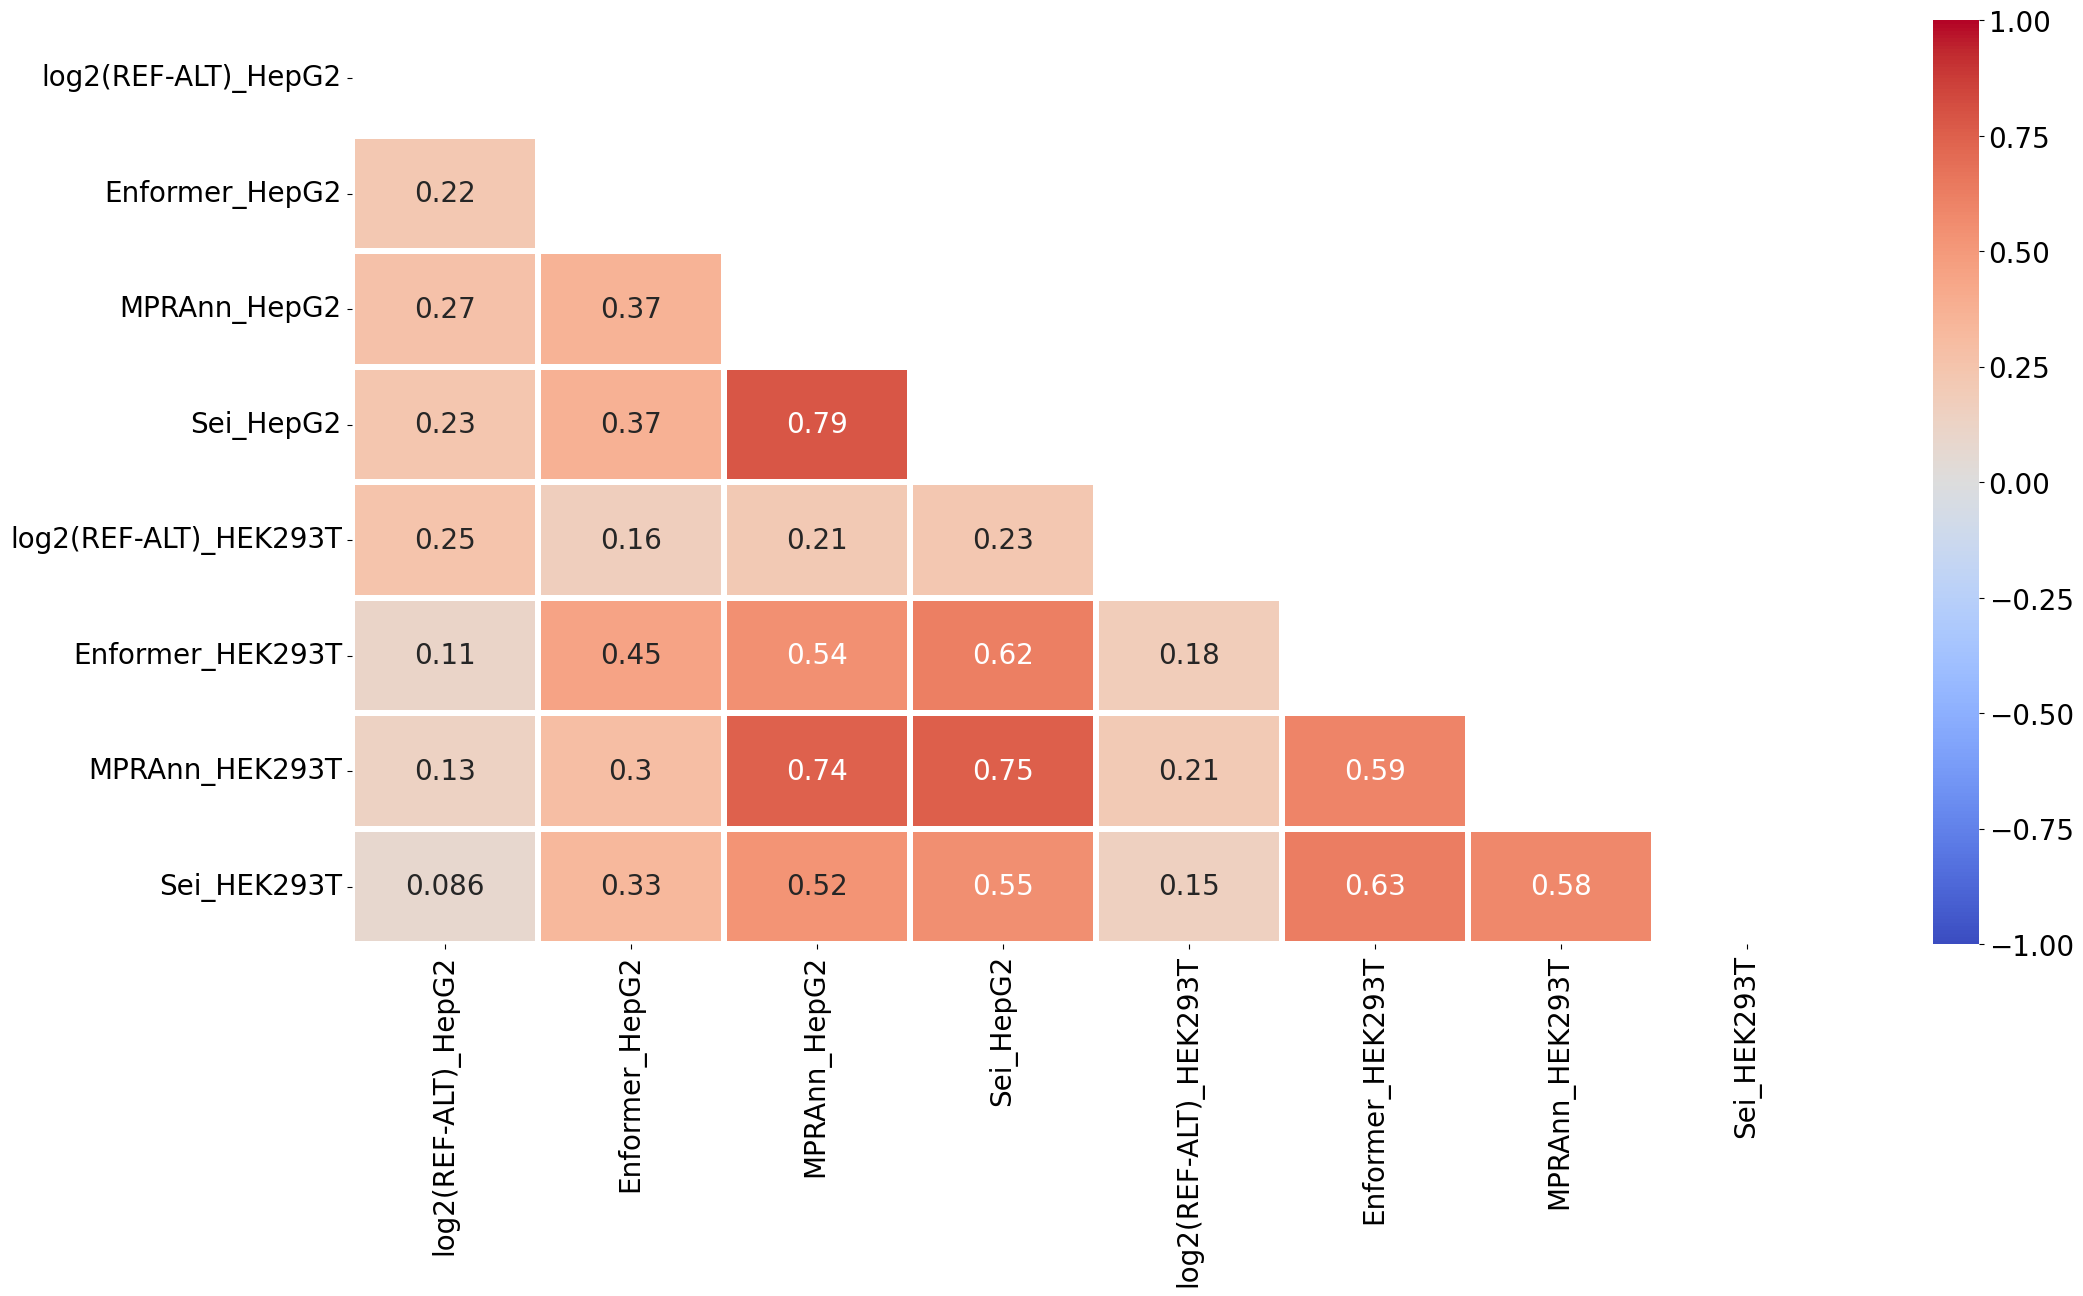

In [129]:
# plot a heatmap of the correlation matrix using seaborn. add title and labels.
plt.figure(figsize=(24,12))

# creating mask
mask = np.triu(np.ones_like(merged.iloc[:,1:].corr()))

sns.heatmap(merged.iloc[:,1:].corr(method="pearson"), linewidths=3, annot=True, cmap='coolwarm', mask=mask, vmin=-1, vmax=1)

# decrease font size
plt.rcParams.update({'font.size': 20})

# save plot as svg
# plt.savefig('enf_mprann_sei_DNase.svg', format='svg', dpi=1200, bbox_inches="tight")
plt.show()